In [240]:
import numpy as np
import random
import pandas as pd
import json
import sqlite3
import sqlglot
import re
from nltk.stem import WordNetLemmatizer
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

random_var = 1
np.random.seed(random_var)
random.seed(random_var)

In [241]:
import nltk

nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Mert\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Mert\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# 1 Data

The data is availale at https://yale-lily.github.io/spider

The "spider_data/spider_data/database/soccer_1/" and "spider_data/spider_data/test_database/soccer_1/" folders were removed, because they were too big.

## 1.1 Data structure

The data contains natural text used to generate SQL queries and the according SQL queries and tables.

The data is already split into train, test and validation datasets.

In the "database" and "test_database" subfolders the tables and the actual data is saved for different topics. For each topic the following files are provided:

- [topic].sqlite: working database
- schema.sql: structured data

"train_spider.json", "train_others.json", "dev.json" and "test.json" contain the natural text and the according SQL queries.

- train_spider and train_others: used for training
- dev: used for validation
- test: used for testing

"tables.json" and "test_tables.json" contain metadata of all tables.

## 1.2 Data exploration

In [242]:
# load data
data = Path("spider_data/spider_data")

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

# natural text and sql queries
train = load_json(data / "train_spider.json")
train_others = load_json(data / "train_others.json")
validation = load_json(data / "dev.json")
test = load_json(data / "test.json")

train_df = pd.DataFrame(train)
train_others_df = pd.DataFrame(train_others)
validation_df = pd.DataFrame(validation)
test_df = pd.DataFrame(test)

# metadata
tables = load_json(data / "tables.json")
test_tables = load_json(data / "test_tables.json")

tables_df = pd.DataFrame(tables)
test_tables_df = pd.DataFrame(test_tables)

In [243]:
train_df.head(5)

,db_id,query,query_toks,query_toks_no_value,question,question_toks,sql
0,department_management,SELECT count(*) FROM head WHERE age > 56,"[SELECT, count, (, *, ), FROM, head, WHERE, ag...","[select, count, (, *, ), from, head, where, ag...",How many heads of the departments are older th...,"[How, many, heads, of, the, departments, are, ...","{'from': {'table_units': [['table_unit', 1]], ..."
1,department_management,"SELECT name , born_state , age FROM head ORD...","[SELECT, name, ,, born_state, ,, age, FROM, he...","[select, name, ,, born_state, ,, age, from, he...","List the name, born state and age of the heads...","[List, the, name, ,, born, state, and, age, of...","{'from': {'table_units': [['table_unit', 1]], ..."
2,department_management,"SELECT creation , name , budget_in_billions ...","[SELECT, creation, ,, name, ,, budget_in_billi...","[select, creation, ,, name, ,, budget_in_billi...","List the creation year, name and budget of eac...","[List, the, creation, year, ,, name, and, budg...","{'from': {'table_units': [['table_unit', 0]], ..."
3,department_management,"SELECT max(budget_in_billions) , min(budget_i...","[SELECT, max, (, budget_in_billions, ), ,, min...","[select, max, (, budget_in_billions, ), ,, min...",What are the maximum and minimum budget of the...,"[What, are, the, maximum, and, minimum, budget...","{'from': {'table_units': [['table_unit', 0]], ..."
4,department_management,SELECT avg(num_employees) FROM department WHER...,"[SELECT, avg, (, num_employees, ), FROM, depar...","[select, avg, (, num_employees, ), from, depar...",What is the average number of employees of the...,"[What, is, the, average, number, of, employees...","{'from': {'table_units': [['table_unit', 0]], ..."


In [244]:
tables_df.head(5)

,column_names,column_names_original,column_types,db_id,foreign_keys,primary_keys,table_names,table_names_original
0,"[[-1, *], [0, perpetrator id], [0, people id],...","[[-1, *], [0, Perpetrator_ID], [0, People_ID],...","[text, number, number, text, number, text, tex...",perpetrator,"[[2, 9]]","[1, 9]","[perpetrator, people]","[perpetrator, people]"
1,"[[-1, *], [0, building], [0, room number], [0,...","[[-1, *], [0, building], [0, room_number], [0,...","[text, text, text, number, text, text, number,...",college_2,"[[9, 4], [13, 4], [19, 1], [20, 2], [15, 7], [...","[1, 4, 7, 11, 15, 22, 27, 31, 37, 39, 45]","[classroom, department, course, instructor, se...","[classroom, department, course, instructor, se..."
2,"[[-1, *], [0, id], [0, city], [0, country], [0...","[[-1, *], [0, id], [0, City], [0, Country], [0...","[text, number, text, text, text, text, text, n...",flight_company,"[[20, 7], [19, 1]]","[1, 7, 13]","[airport, operate company, flight]","[airport, operate_company, flight]"
3,"[[-1, *], [0, institution id], [0, name], [0, ...","[[-1, *], [0, instID], [0, name], [0, country]...","[text, number, text, text, number, text, text,...",icfp_1,"[[11, 7], [10, 1], [9, 4]]","[1, 4, 7, 9]","[institution, authors, papers, authorship count]","[Inst, Authors, Papers, Authorship]"
4,"[[-1, *], [0, body builder id], [0, people id]...","[[-1, *], [0, Body_Builder_ID], [0, People_ID]...","[text, number, number, number, number, number,...",body_builder,"[[2, 6]]","[1, 6]","[body builder, people]","[body_builder, people]"


- column_names: [idx of table_names, name of column]
- foreign_keys: [linked idx 1 of column_names, linked idx 2 of column_names]
- primary_keys: primary idx of column_names

In [245]:
# id = name of sqlite file

# ids used in sql queries
train_ids = {i["db_id"] for i in train}
train_others_ids = {i["db_id"] for i in train_others}
validation_ids = {i["db_id"] for i in validation}
test_ids = {i["db_id"] for i in test}

# ids available in tables and test_tables
table_ids = {i["db_id"] for i in tables}
test_table_ids = {i["db_id"] for i in test_tables}

In [246]:
# test sqlite files
def test_query(id, folder, query):
    sqlite_path = data / folder / id / f"{id}.sqlite"

    if not sqlite_path.exists():
        print("sqlite file does not exist")
        return
    
    try:
        conn = sqlite3.connect(sqlite_path)
        cursor = conn.cursor()
        cursor.execute(query)
        result = cursor.fetchall()
        conn.close()
        print(query)
        print(result)
    
    except Exception as e:
        print(e)

test_query(id=train[0]["db_id"], folder="database", query=train[0]["query"])

SELECT count(*) FROM head WHERE age  >  56
[(5,)]


In [247]:
# function to check if all ids used in sql queries actually exist
def check_ids(ids, folder, meta_data):
    sqlite_list = []
    sql_list = []
    metadata_list = []

    for id in ids:
        sqlite_path = data / folder / id / f"{id}.sqlite"
        sql_path = data / folder / id / "schema.sql"

        if not sqlite_path.exists():
            sqlite_list.append(id)

        if not sql_path.exists():
            sql_list.append(id)

        if id not in meta_data:
            metadata_list.append(id)

    print("sqlite_list: ", sqlite_list)
    print("sql_list: ", sql_list)
    print("metadata_list: ", metadata_list)

print("train_ids: ")
check_ids(ids=train_ids, folder="database", meta_data=table_ids)
print("train_others_ids: ")
check_ids(ids=train_others_ids, folder="database", meta_data=table_ids)
print("validation_ids: ")
check_ids(ids=validation_ids, folder="database", meta_data=table_ids)
print("test_ids: ")
check_ids(ids=test_ids, folder="test_database", meta_data=test_table_ids)

train_ids: 
sqlite_list:  ['soccer_1']
sql_list:  ['inn_1', 'icfp_1', 'soccer_1', 'chinook_1', 'twitter_1', 'small_bank_1', 'company_1', 'student_1', 'college_1', 'formula_1', 'epinions_1', 'college_2', 'wine_1', 'flight_4']
metadata_list:  []
train_others_ids: 
sqlite_list:  []
sql_list:  []
metadata_list:  []
validation_ids: 
sqlite_list:  []
sql_list:  ['voter_1', 'wta_1', 'flight_2', 'world_1', 'car_1']
metadata_list:  []
test_ids: 
sqlite_list:  []
sql_list:  ['art_1', 'bakery_1']
metadata_list:  []


schema.sql is not available for every database.

In [248]:
# remove all data points where the id "soccer_1" is used
train = [i for i in train if i["db_id"] != "soccer_1"]
train_ids = {i["db_id"] for i in train}

In [249]:
# summary df
datasets_dfs = {
    "train": train_df,
    "train_others": train_others_df,
    "validation": validation_df,
    "test": test_df
}

summary = []

for name, df in datasets_dfs.items():
    df["query_lower"] = df["query"].str.lower()
    df["query_len"] = df["query"].str.len()
    df["question_len"] = df["question"].str.len()

    row = {
        "dataset": name,
        "dataset_size": len(df),
        "number_databases": df["db_id"].nunique(),

        "query_len_mean": df["query_len"].mean(),
        "query_len_min": df["query_len"].min(),
        "query_len_25": df["query_len"].quantile(0.25),
        "query_len_50": df["query_len"].quantile(0.50),
        "query_len_75": df["query_len"].quantile(0.75),
        "query_len_max": df["query_len"].max(),

        "question_len_mean": df["question_len"].mean(),
        "question_len_min": df["question_len"].min(),
        "question_len_25": df["question_len"].quantile(0.25),
        "question_len_50": df["question_len"].quantile(0.50),
        "question_len_75": df["question_len"].quantile(0.75),
        "question_len_max": df["question_len"].max(),
    }

    for i in ["where", "order by", "join", "group by"]:
        row[i] = df["query_lower"].str.contains(i).sum()

    summary.append(row)

summary_df = pd.DataFrame(summary)
summary_df

,dataset,dataset_size,number_databases,query_len_mean,query_len_min,query_len_25,query_len_50,query_len_75,query_len_max,question_len_mean,question_len_min,question_len_25,question_len_50,question_len_75,question_len_max,where,order by,join,group by
0,train,7000,140,109.642429,18,62.0,93.0,146.25,577,70.864857,16,54.0,69.0,86.00,224,3502,1628,2783,1775
1,train_others,1659,6,178.667872,23,89.0,176.0,247.00,438,48.566004,3,36.0,46.0,59.00,139,1589,175,1041,178
2,validation,1034,20,106.693424,20,63.0,89.0,138.00,422,68.048356,18,52.0,66.0,81.75,174,493,237,408,277
3,test,2147,40,113.490918,22,61.0,93.0,147.00,608,69.003260,22,54.0,67.0,83.00,185,951,510,862,613


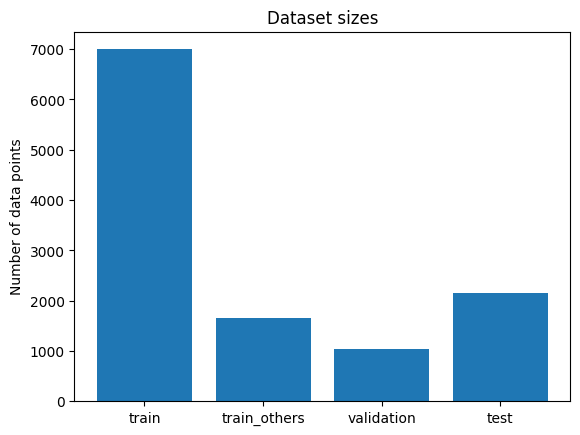

In [250]:
# dataset sizes
plt.bar(summary_df["dataset"], summary_df["dataset_size"])
plt.title("Dataset sizes")
plt.ylabel("Number of data points")
plt.show()

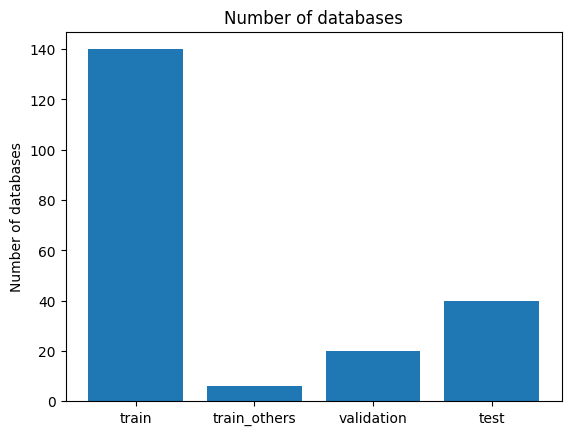

In [251]:
# number of databases
plt.bar(summary_df["dataset"], summary_df["number_databases"])
plt.title("Number of databases")
plt.ylabel("Number of databases")
plt.show()

train_others has fewer databases compared to data points.

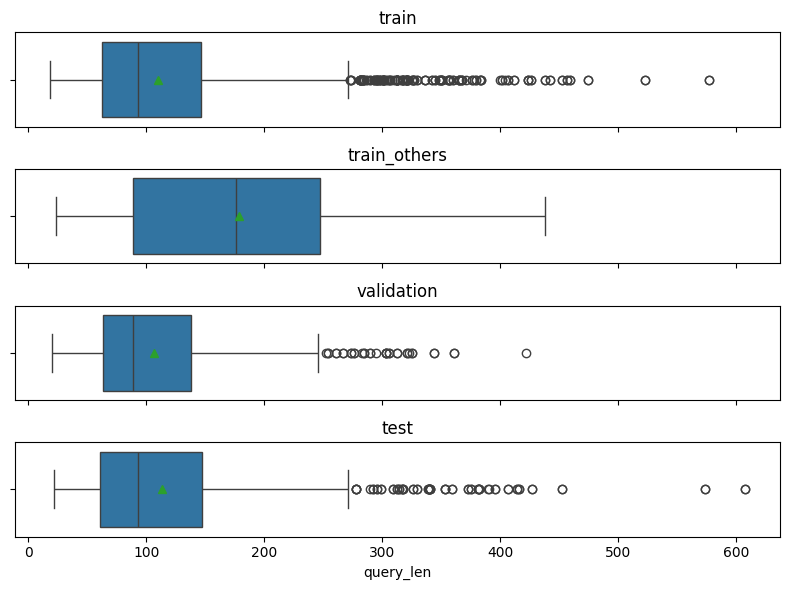

In [252]:
# sql query lenghts
fig, axes = plt.subplots(4, 1, figsize=(8, 6), sharex=True)

sns.boxplot(x=train_df["query_len"], ax=axes[0], orient="h", showmeans=True)
axes[0].set_title("train")

sns.boxplot(x=train_others_df["query_len"], ax=axes[1], orient="h", showmeans=True)
axes[1].set_title("train_others")

sns.boxplot(x=validation_df["query_len"], ax=axes[2], orient="h", showmeans=True)
axes[2].set_title("validation")

sns.boxplot(x=test_df["query_len"], ax=axes[3], orient="h", showmeans=True)
axes[3].set_title("test")

plt.tight_layout()
plt.show()

train_others has longer sql queries, but no outliers.

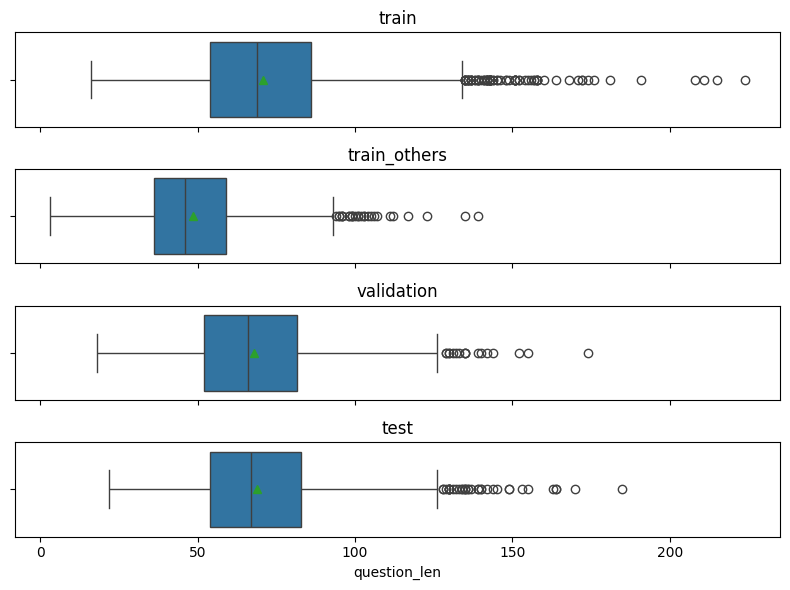

In [253]:
# question lenghts
fig, axes = plt.subplots(4, 1, figsize=(8, 6), sharex=True)

sns.boxplot(x=train_df["question_len"], ax=axes[0], orient="h", showmeans=True)
axes[0].set_title("train")

sns.boxplot(x=train_others_df["question_len"], ax=axes[1], orient="h", showmeans=True)
axes[1].set_title("train_others")

sns.boxplot(x=validation_df["question_len"], ax=axes[2], orient="h", showmeans=True)
axes[2].set_title("validation")

sns.boxplot(x=test_df["question_len"], ax=axes[3], orient="h", showmeans=True)
axes[3].set_title("test")

plt.tight_layout()
plt.show()

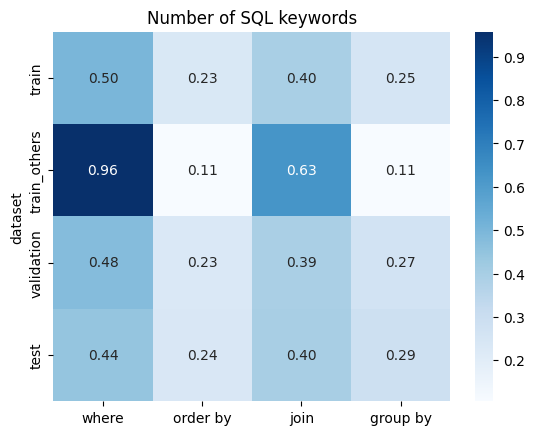

In [254]:
# number of sql keywords per data point
heatmap_df = summary_df.copy()

# normalize
for i in ["where", "order by", "join", "group by"]:
    heatmap_df[i] = heatmap_df[i] / heatmap_df["dataset_size"]

heatmap_df = heatmap_df.set_index("dataset")[["where", "order by", "join", "group by"]]
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Number of SQL keywords")
plt.show()

train_others has more "where" and "join", but fewer "order by" and "group by".

Overall, train, validation and test set seem to be similar. train_others seems to be a more complex dataset.

## 1.3 Data preparation

In [255]:
# assign tables, columns and foreign keys to databases
def format_databases(tables_input):
    databases = {}

    for db in tables_input:
        id = db["db_id"]

        table_names = db["table_names_original"]
        column_names = db["column_names_original"]
        column_types = db["column_types"]
        foreign_keys = db["foreign_keys"]

        tables_dict = {i: [] for i in table_names}

        # add columns and types to tables
        for idx_iteration, (idx_table, name) in enumerate(column_names):
            if idx_table != -1:
                tables_dict_item = table_names[idx_table]
                tables_dict[tables_dict_item].append((name, column_types[idx_iteration]))

        # add foreign keys
        foreign_keys_list = []
        for col1, col2 in foreign_keys:
            idx_table1, col_name1 = column_names[col1]
            idx_table2, col_name2 = column_names[col2]

            table_name1 = table_names[idx_table1]
            table_name2 = table_names[idx_table2]

            foreign_keys_list.append((f"{table_name1}.{col_name1}", f"{table_name2}.{col_name2}"))

        databases[id] = {
            "tables": tables_dict,
            "foreign_keys": foreign_keys_list
        }

    return databases

In [256]:
# get tables, columns and foreign keys of a specific database
def get_database_info(id):
    database_info_list = []

    for table, columns in id["tables"].items():
        col_names = ", ".join(col[0] for col in columns)
        database_info_list.append(f"table={table}, cols=[{col_names}]")

    for foreign_keys in id["foreign_keys"]:
        database_info_list.append(f"foreign_keys=[{foreign_keys[0]}, {foreign_keys[1]}]")

    database_info = "; ".join(database_info_list)
    return database_info

In [257]:
# normalize sql queries
def get_normalized_query(query):
    try:
        # transform to custom structure from library
        parsed = sqlglot.parse_one(query)

        # create map for tables and aliases
        map_alias = {}
        for table in parsed.find_all(sqlglot.exp.Table):
            if table.alias:
                map_alias[table.alias.name] = table.name

        # remove aliases
        for column in parsed.find_all(sqlglot.exp.Column):
            if column.table:

                if column.table.name in map_alias:
                    column.set("table", map_alias[column.table.name])

        for table in parsed.find_all(sqlglot.exp.Table):
            if table.alias:
                table.set("alias", None)

        # transform back to text
        normalized = parsed.sql(
            dialect="sqlite",
            pretty=False,
            normalize=True
        )

        normalized = normalized.lower()
        return normalized
    
    except Exception:
        # minimal normalization
        query = query.lower()
        query = query.replace("\n", " ")
        query = " ".join(query.split())
        return query



In [258]:
# linking to tables, columns and numbers

# used to convert word to base of word
lemmatizer = WordNetLemmatizer()

def get_links(question, id):

    links = set()
    links_columns = set()
    links_numbers = set()

    # transform question to tokens
    tokens = question.lower().split()
    tokens = [lemmatizer.lemmatize(i) for i in tokens]

    # check if token matches table or column
    for table, columns in id["tables"].items():
        table = lemmatizer.lemmatize(table)

        if table in tokens:
            links.add(f"table={table}")

        for column in columns:
            column = lemmatizer.lemmatize(column[0])

            if column in tokens:
                links.add(f"column={table}.{column}")
                links_columns.add(column)

    # find numbers
    numbers = re.findall(r"\d+", question)
    for number in numbers:
        links.add(f"value={number}")
        links_numbers.add(number)

    links = ", ".join(sorted(links))
    return links, links_columns, links_numbers


In [259]:
# create final input to the model
def create_input(question, database_info, links):
    input = f"Transform this question to a SQL query: Question: {question}, Database_info: {database_info}, Links: {links}"
    return input


In [260]:
# train pipeline
def train_pipeline(data, tables, normalize_query=True):
    data_list = []
    databases = format_databases(tables)

    for i in data:
        id = databases[i["db_id"]]
        question = i["question"]
        query = i["query"]

        database_info = get_database_info(id=id)

        if normalize_query == True:
            query = get_normalized_query(query=query)

        links, _, _ = get_links(question=question, id=id)

        input1 = create_input(question=question, database_info=database_info, links=links)

        input2 = {
            "input": input1,
            "expected": query,
            "id": i["db_id"]
        }
        data_list.append(input2)

    return data_list

train_data = train_pipeline(data=train, tables=tables)
train_others_data = train_pipeline(data=train_others, tables=tables)
validation_data = train_pipeline(data=validation, tables=tables)

test_data = train_pipeline(data=test, tables=test_tables, normalize_query=False)

In [261]:
# combine train and train_others
train_data_combined = train_data + train_others_data
train_data_combined[0]

{'input': 'Transform this question to a SQL query: Question: How many heads of the departments are older than 56 ?, Database_info: table=department, cols=[Department_ID, Name, Creation, Ranking, Budget_in_Billions, Num_Employees]; table=head, cols=[head_ID, name, born_state, age]; table=management, cols=[department_ID, head_ID, temporary_acting]; foreign_keys=[management.head_ID, head.head_ID]; foreign_keys=[management.department_ID, department.Department_ID], Links: table=department, table=head, value=56',
 'expected': 'select count(*) from head where age > 56',
 'id': 'department_management'}

## 1.4 Data augmentation

In [262]:
# combine train and train_others
train_combined = train + train_others

In [263]:
# augment columns of query
def augment_columns(query, id, links_columns):
    try:
        
        # transform to custom structure from library
        parsed = sqlglot.parse_one(query)
        select = parsed.find(sqlglot.exp.Select)

        # count how often a column is used (only change columns if not used elsewhere)
        column_count = {}
        for column in parsed.find_all(sqlglot.exp.Column):
            key = column.name
            column_count[key] = column_count.get(key, 0) + 1

        # column types
        column_types = {}
        for table, columns in id["tables"].items():
            for column, column_type in columns:
                column_types[column] = column_type




        # check if columns can be replaced
        replacements_possible = []

        for expression in select.expressions:
            if not isinstance(expression, sqlglot.exp.Column):
                continue

            column = expression.name

            # get table name
            table = ""
            for table, columns in id["tables"].items():
                for col, _ in columns:
                    if col == column:
                        table_of_column = table

            # check if column is linked
            if column not in links_columns:
                continue

            # check if column is not used elsewhere
            if column_count.get(column, 0) > 1:
                continue

            # choose possible replacement columns
            replacement_columns = [
                col for col, column_type in id["tables"][table_of_column] if col != column and column_type == column_types[column]
            ]

            if replacement_columns:
                replacements_possible.append((expression, replacement_columns))

            



        # change columns
        replacements = []

        for expression, replacement_columns in replacements_possible:
            for column_new in replacement_columns:
                parsed_copy = parsed.copy()
  
                select_copy = parsed_copy.find(sqlglot.exp.Select)
                expression_copy = list(select_copy.expressions)[select.expressions.index(expression)]

                expression_copy.set("this", sqlglot.exp.to_identifier(column_new))

                query_new = parsed_copy.sql(
                    dialect="sqlite",
                    pretty=False,
                    normalize=True
                )

                replacements.append((query_new, {expression.name: column_new}))

        

        return replacements
        
    except Exception:
        return []

In [264]:
# augment numbers of query
def augment_numbers(query, links_numbers):
    try:
        parsed = sqlglot.parse_one(query)

        replacements = []

        for number in parsed.find_all(sqlglot.exp.Literal):
            
            if not number.is_number:
                continue

            number_this = number.this

            if number_this not in links_numbers:
                continue

            number_float = float(number_this)

            # create new number
            number_new = str(int(number_float * random.uniform(0.1, 10)))
            
            parsed_copy = parsed.copy()

            # change numbers
            for number_copy in parsed_copy.find_all(sqlglot.exp.Literal):
                if number_copy == number:
                    number_copy.set("this", number_new)

            query_new = parsed_copy.sql(
                    dialect="sqlite",
                    pretty=False,
                    normalize=True
            )

            replacements.append((query_new, {number_this: number_new}))

        return replacements
        
    except Exception:
        return []

In [265]:
# augment question
def augment_question(question, replacements_columns=None, replacements_numbers=None):
    question_new = question

    if replacements_columns:
        for column_old, column_new in replacements_columns.items():
            pattern = r"\b" + re.escape(column_old) + r"\b"
            question_new = re.sub(pattern, column_new, question_new)

    if replacements_numbers:
        for number_old, number_new in replacements_numbers.items():
            pattern = r"\b" + re.escape(number_old) + r"\b"
            question_new = re.sub(pattern, number_new, question_new)

    return question_new

In [266]:
# augmentation pipeline
def augmentation_pipeline(data, tables, normalize_query=True):
    data_list = []
    databases = format_databases(tables)

    for i in data:
        id = databases[i["db_id"]]
        question = i["question"]
        query = i["query"]

        database_info = get_database_info(id=id)
        query = get_normalized_query(query=query)
        links, links_columns, links_numbers = get_links(question=question, id=id)

        # column and number augmentation
        columns_augmented = augment_columns(query=query, id=id, links_columns=links_columns)
        numbers_augmented = augment_numbers(query=query, links_numbers=links_numbers)

        # question augmentation
        for query_new, column_new in columns_augmented:

            if normalize_query == True:
                query_new = get_normalized_query(query=query_new)

            question_new = augment_question(question=question, replacements_columns=column_new)
            links, _, _ = get_links(question=question_new, id=id)

            input1 = create_input(question=question_new, database_info=database_info, links=links)

            input2 = {
                "input": input1,
                "expected": query_new,
                "id": i["db_id"]
            }
            data_list.append(input2)

        for query_new, number_new in numbers_augmented:

            if normalize_query == True:
                query_new = get_normalized_query(query=query_new)
            
            question_new = augment_question(question=question, replacements_numbers=number_new)
            links, _, _ = get_links(question=question_new, id=id)

            input1 = create_input(question=question_new, database_info=database_info, links=links)

            input2 = {
                "input": input1,
                "expected": query_new,
                "id": i["db_id"]
            }
            data_list.append(input2)

    return data_list

train_data_combined_augmented = augmentation_pipeline(data=train_combined, tables=tables)
print(len(train_data_combined_augmented))

3222


In [267]:
print(train_data_combined[0])
print(train_data_combined_augmented[0])

{'input': 'Transform this question to a SQL query: Question: How many heads of the departments are older than 56 ?, Database_info: table=department, cols=[Department_ID, Name, Creation, Ranking, Budget_in_Billions, Num_Employees]; table=head, cols=[head_ID, name, born_state, age]; table=management, cols=[department_ID, head_ID, temporary_acting]; foreign_keys=[management.head_ID, head.head_ID]; foreign_keys=[management.department_ID, department.Department_ID], Links: table=department, table=head, value=56', 'expected': 'select count(*) from head where age > 56', 'id': 'department_management'}
{'input': 'Transform this question to a SQL query: Question: How many heads of the departments are older than 80 ?, Database_info: table=department, cols=[Department_ID, Name, Creation, Ranking, Budget_in_Billions, Num_Employees]; table=head, cols=[head_ID, name, born_state, age]; table=management, cols=[department_ID, head_ID, temporary_acting]; foreign_keys=[management.head_ID, head.head_ID]; fo

In [268]:
# combine train_combined and train_combined_augmented
train_data_all = train_data_combined + train_data_combined_augmented

In [269]:
test_query(id=train_data_all[0]["id"], folder="database", query=train_data_all[0]["expected"])

select count(*) from head where age > 56
[(5,)]


In [270]:
import math
import random
import re
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [271]:
import torch
print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version in torch:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

2.6.0+cu124
CUDA available: True
CUDA version in torch: 12.4
GPU count: 1
GPU name: NVIDIA GeForce RTX 3060


In [272]:
import sys
print(sys.executable)

c:\Users\Mert\AppData\Local\Programs\Python\Python310\python.exe


In [273]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [274]:
import re

def simple_tokenize(text):
    text = str(text).lower().strip()

    pattern = r"""
        [a-zA-Z_][a-zA-Z0-9_\.]*     
        |>=|<=|!=|=|<|>              
        |\*|\(|\)|,|;                
        |'[^']*'                     
        |"[^"]*"                     
        |\d+\.\d+                    
        |\d+                         
    """
    return re.findall(pattern, text, re.VERBOSE)

In [275]:
def filter_by_length(data, max_input_tokens=180, max_output_tokens=80):
    filtered = []
    for ex in data:
        in_len = len(simple_tokenize(ex["input"]))
        out_len = len(simple_tokenize(ex["expected"]))
        if in_len <= max_input_tokens and out_len <= max_output_tokens:
            filtered.append(ex)
    return filtered

In [276]:
train_data_all = train_data + train_others_data

train_data_all = filter_by_length(train_data_all, max_input_tokens=180, max_output_tokens=80)
validation_data_filtered = filter_by_length(validation_data, max_input_tokens=180, max_output_tokens=80)

print("Filtered train size:", len(train_data_all))
print("Filtered validation size:", len(validation_data_filtered))

Filtered train size: 6120
Filtered validation size: 874


In [277]:
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

class Vocab:
    def __init__(self, min_freq=1):
        self.min_freq = min_freq
        self.token_to_idx = {}
        self.idx_to_token = {}
        
    def build(self, token_lists):
        counter = Counter()
        for tokens in token_lists:
            counter.update(tokens)
        
        specials = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
        self.token_to_idx = {tok: i for i, tok in enumerate(specials)}
        
        idx = len(specials)
        for token, freq in counter.items():
            if freq >= self.min_freq and token not in self.token_to_idx:
                self.token_to_idx[token] = idx
                idx += 1
        
        self.idx_to_token = {i: tok for tok, i in self.token_to_idx.items()}
    
    def encode(self, tokens):
        unk_idx = self.token_to_idx[UNK_TOKEN]
        return [self.token_to_idx.get(tok, unk_idx) for tok in tokens]
    
    def decode(self, indices, stop_at_eos=True):
        tokens = []
        for idx in indices:
            token = self.idx_to_token.get(int(idx), UNK_TOKEN)
            if stop_at_eos and token == EOS_TOKEN:
                break
            tokens.append(token)
        return tokens
    
    def __len__(self):
        return len(self.token_to_idx)

In [278]:
train_input_tokens = [simple_tokenize(ex["input"]) for ex in train_data_all]
train_output_tokens = [simple_tokenize(ex["expected"]) for ex in train_data_all]

val_input_tokens = [simple_tokenize(ex["input"]) for ex in validation_data_filtered]
val_output_tokens = [simple_tokenize(ex["expected"]) for ex in validation_data_filtered]

input_vocab = Vocab(min_freq=2)
output_vocab = Vocab(min_freq=1)

input_vocab.build(train_input_tokens)
output_vocab.build(train_output_tokens)

print("Input vocab size:", len(input_vocab))
print("Output vocab size:", len(output_vocab))
print("Train examples:", len(train_data_all))
print("Validation examples:", len(validation_data_filtered))

Input vocab size: 4274
Output vocab size: 3192
Train examples: 6120
Validation examples: 874


In [279]:
class TextToSQLDataset(Dataset):
    def __init__(self, examples, input_vocab, output_vocab):
        self.examples = examples
        self.input_vocab = input_vocab
        self.output_vocab = output_vocab
        
    def __len__(self):
        return len(self.examples)
    
    def __getitem__(self, idx):
        ex = self.examples[idx]
        
        src_tokens = simple_tokenize(ex["input"])
        trg_tokens = simple_tokenize(ex["expected"])
        
        src_ids = self.input_vocab.encode(src_tokens) + [self.input_vocab.token_to_idx[EOS_TOKEN]]
        trg_ids = [self.output_vocab.token_to_idx[SOS_TOKEN]] + self.output_vocab.encode(trg_tokens) + [self.output_vocab.token_to_idx[EOS_TOKEN]]
        
        return {
            "src_ids": torch.tensor(src_ids, dtype=torch.long),
            "trg_ids": torch.tensor(trg_ids, dtype=torch.long),
            "id": ex.get("id", idx)
        }

In [280]:
PAD_IDX_IN = input_vocab.token_to_idx[PAD_TOKEN]
PAD_IDX_OUT = output_vocab.token_to_idx[PAD_TOKEN]

def collate_fn(batch):
    src_seqs = [item["src_ids"] for item in batch]
    trg_seqs = [item["trg_ids"] for item in batch]
    ids = [item["id"] for item in batch]
    
    src_lengths = torch.tensor([len(seq) for seq in src_seqs], dtype=torch.long)
    
    max_src_len = max(len(seq) for seq in src_seqs)
    max_trg_len = max(len(seq) for seq in trg_seqs)
    
    padded_src = torch.full((len(batch), max_src_len), PAD_IDX_IN, dtype=torch.long)
    padded_trg = torch.full((len(batch), max_trg_len), PAD_IDX_OUT, dtype=torch.long)
    
    for i, seq in enumerate(src_seqs):
        padded_src[i, :len(seq)] = seq
        
    for i, seq in enumerate(trg_seqs):
        padded_trg[i, :len(seq)] = seq
    
    return padded_src, src_lengths, padded_trg, ids

In [281]:
BATCH_SIZE = 16

train_dataset = TextToSQLDataset(train_data_all, input_vocab, output_vocab)
val_dataset = TextToSQLDataset(validation_data_filtered, input_vocab, output_vocab)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [282]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, enc_hidden_dim, dec_hidden_dim, dropout):
        super().__init__()

        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX_IN)

        self.rnn = nn.LSTM(
            emb_dim,
            enc_hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc_hidden = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim)
        self.fc_cell = nn.Linear(enc_hidden_dim * 2, dec_hidden_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded,
            src_lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        packed_outputs, (hidden, cell) = self.rnn(packed)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_outputs, batch_first=True)

        # hidden: [2, batch, enc_hidden_dim]
        # cell:   [2, batch, enc_hidden_dim]

        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        cell_cat = torch.cat((cell[-2], cell[-1]), dim=1)

        hidden = torch.tanh(self.fc_hidden(hidden_cat))   # [batch, dec_hidden_dim]
        cell = torch.tanh(self.fc_cell(cell_cat))         # [batch, dec_hidden_dim]

        return outputs, hidden, cell

In [283]:
class AdditiveAttention(nn.Module):
    def __init__(self, enc_hidden_dim, dec_hidden_dim):
        super().__init__()
        self.attn = nn.Linear(enc_hidden_dim * 2 + dec_hidden_dim, dec_hidden_dim)
        self.v = nn.Linear(dec_hidden_dim, 1, bias=False)
        
    def forward(self, hidden, encoder_outputs, src_mask):
        # hidden: [batch, dec_hidden_dim]
        # encoder_outputs: [batch, src_len, enc_hidden_dim*2]
        batch_size = encoder_outputs.shape[0]
        src_len = encoder_outputs.shape[1]
        
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)  # [batch, src_len, dec_hidden_dim]
        
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)  # [batch, src_len]
        
        attention = attention.masked_fill(src_mask == 0, -1e10)
        
        return torch.softmax(attention, dim=1)

In [284]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, enc_hidden_dim, dec_hidden_dim, attention, dropout):
        super().__init__()

        self.output_dim = output_dim
        self.attention = attention

        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX_OUT)

        self.rnn = nn.LSTM(
            emb_dim + enc_hidden_dim * 2,
            dec_hidden_dim,
            batch_first=True
        )

        self.fc_out = nn.Linear(
            emb_dim + enc_hidden_dim * 2 + dec_hidden_dim,
            output_dim
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, input_token, hidden, cell, encoder_outputs, src_mask):
        # input_token: [batch]
        # hidden: [batch, dec_hidden_dim]
        # cell: [batch, dec_hidden_dim]

        input_token = input_token.unsqueeze(1)                 # [batch, 1]
        embedded = self.dropout(self.embedding(input_token))   # [batch, 1, emb_dim]

        attn_weights = self.attention(hidden, encoder_outputs, src_mask)  # [batch, src_len]
        attn_weights = attn_weights.unsqueeze(1)                           # [batch, 1, src_len]

        context = torch.bmm(attn_weights, encoder_outputs)    # [batch, 1, enc_hidden_dim*2]

        rnn_input = torch.cat((embedded, context), dim=2)     # [batch, 1, emb+context]

        output, (hidden_new, cell_new) = self.rnn(
            rnn_input,
            (hidden.unsqueeze(0), cell.unsqueeze(0))
        )

        output = output.squeeze(1)
        context = context.squeeze(1)
        embedded = embedded.squeeze(1)
        hidden_new = hidden_new.squeeze(0)
        cell_new = cell_new.squeeze(0)

        prediction = self.fc_out(torch.cat((output, context, embedded), dim=1))

        return prediction, hidden_new, cell_new, attn_weights.squeeze(1)

In [285]:
import random
import torch

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    # do NOT use torch.cuda.manual_seed_all for now

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [286]:
import torch
import torch.nn as nn
import random

class TestModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.x = 1

    def forward(self, a):
        return a

print("class defined ok")

class defined ok


In [287]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Tiny(nn.Module):
    def __init__(self):
        super().__init__()
        self.lin = nn.Linear(3, 4)

    def forward(self, x):
        return self.lin(x)

m = Tiny().to(device)
x = torch.randn(2, 3).to(device)
y = m(x)
print(y.shape)

torch.Size([2, 4])


In [288]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, src_pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_pad_idx = src_pad_idx

    def create_src_mask(self, src):
        return (src != self.src_pad_idx)

    def forward(self, src, src_lengths, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.output_dim

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=src.device)

        encoder_outputs, hidden, cell = self.encoder(src, src_lengths)
        src_mask = self.create_src_mask(src)

        input_token = trg[:, 0]  # <sos>

        for t in range(1, trg_len):
            output, hidden, cell, _ = self.decoder(
                input_token, hidden, cell, encoder_outputs, src_mask
            )
            outputs[:, t, :] = output

            top1 = output.argmax(1)
            teacher_force = random.random() < teacher_forcing_ratio
            input_token = trg[:, t] if teacher_force else top1

        return outputs

In [289]:
INPUT_DIM = len(input_vocab)
OUTPUT_DIM = len(output_vocab)

ENC_EMB_DIM = 256
DEC_EMB_DIM = 256
ENC_HIDDEN_DIM = 256
DEC_HIDDEN_DIM = 256
DROPOUT = 0.2

attention = AdditiveAttention(ENC_HIDDEN_DIM, DEC_HIDDEN_DIM)
encoder = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HIDDEN_DIM, DEC_HIDDEN_DIM, DROPOUT)
decoder = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HIDDEN_DIM, DEC_HIDDEN_DIM, attention, DROPOUT)

model = Seq2Seq(encoder, decoder, PAD_IDX_IN).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX_OUT)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print(model)

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(4274, 256, padding_idx=0)
    (rnn): LSTM(256, 256, batch_first=True, bidirectional=True)
    (fc_hidden): Linear(in_features=512, out_features=256, bias=True)
    (fc_cell): Linear(in_features=512, out_features=256, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (decoder): Decoder(
    (attention): AdditiveAttention(
      (attn): Linear(in_features=768, out_features=256, bias=True)
      (v): Linear(in_features=256, out_features=1, bias=False)
    )
    (embedding): Embedding(3192, 256, padding_idx=0)
    (rnn): LSTM(768, 256, batch_first=True)
    (fc_out): Linear(in_features=1024, out_features=3192, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)


In [290]:
def train_epoch(model, loader, optimizer, criterion, teacher_forcing_ratio=0.5, clip=1.0):
    model.train()
    epoch_loss = 0

    for src, src_lengths, trg, _ in loader:
        src = src.to(device)
        src_lengths = src_lengths.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        output = model(src, src_lengths, trg, teacher_forcing_ratio=teacher_forcing_ratio)

        output_dim = output.shape[-1]
        output = output[:, 1:, :].reshape(-1, output_dim)
        trg_gold = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg_gold)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate_epoch(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    
    with torch.no_grad():
        for src, src_lengths, trg, _ in loader:
            src = src.to(device)
            src_lengths = src_lengths.to(device)
            trg = trg.to(device)
            
            output = model(src, src_lengths, trg, teacher_forcing_ratio=0.0)
            
            output_dim = output.shape[-1]
            output = output[:, 1:, :].reshape(-1, output_dim)
            trg_gold = trg[:, 1:].reshape(-1)
            
            loss = criterion(output, trg_gold)
            epoch_loss += loss.item()
    
    return epoch_loss / len(loader)

In [291]:
def predict_sql_beam(model, input_text, input_vocab, output_vocab, max_len=120, beam_width=3, no_repeat_token=True):
    model.eval()

    tokens = simple_tokenize(input_text)
    src_ids = input_vocab.encode(tokens) + [input_vocab.token_to_idx[EOS_TOKEN]]

    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)
    src_lengths = torch.tensor([len(src_ids)], dtype=torch.long).to(device)

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(src_tensor, src_lengths)

    src_mask = model.create_src_mask(src_tensor)

    sos_idx = output_vocab.token_to_idx[SOS_TOKEN]
    eos_idx = output_vocab.token_to_idx[EOS_TOKEN]

    beams = [([sos_idx], hidden, cell, 0.0)]  # (sequence, hidden, cell, score)

    for _ in range(max_len):
        new_beams = []

        for seq, hidden_state, cell_state, score in beams:
            last_token = seq[-1]

            if last_token == eos_idx:
                new_beams.append((seq, hidden_state, cell_state, score))
                continue

            input_token = torch.tensor([last_token], dtype=torch.long, device=device)

            with torch.no_grad():
                output, next_hidden, next_cell, _ = model.decoder(
                    input_token,
                    hidden_state,
                    cell_state,
                    encoder_outputs,
                    src_mask
                )

            log_probs = torch.log_softmax(output, dim=1)
            topk_log_probs, topk_indices = torch.topk(log_probs, beam_width, dim=1)

            for k in range(beam_width):
                next_token = topk_indices[0, k].item()
                next_score = score + topk_log_probs[0, k].item()

                if no_repeat_token and len(seq) >= 2 and next_token == seq[-1] == seq[-2]:
                    continue

                new_seq = seq + [next_token]
                new_beams.append((new_seq, next_hidden, next_cell, next_score))

        beams = sorted(new_beams, key=lambda x: x[3], reverse=True)[:beam_width]

        if all(seq[-1] == eos_idx for seq, _, _, _ in beams):
            break

    best_seq = beams[0][0]

    if best_seq[0] == sos_idx:
        best_seq = best_seq[1:]

    if eos_idx in best_seq:
        best_seq = best_seq[:best_seq.index(eos_idx)]

    pred_tokens = output_vocab.decode(best_seq, stop_at_eos=False)
    return " ".join(pred_tokens)

In [292]:
def token_overlap_score(pred, gold):
    pred_toks = set(simple_tokenize(pred))
    gold_toks = set(simple_tokenize(gold))

    if len(pred_toks) == 0 and len(gold_toks) == 0:
        return 1.0
    if len(pred_toks) == 0 or len(gold_toks) == 0:
        return 0.0

    return len(pred_toks & gold_toks) / len(pred_toks | gold_toks)


def average_token_overlap(model, examples, input_vocab, output_vocab, n_samples=100):
    scores = []
    subset = examples[:n_samples]

    for ex in subset:
        pred = predict_sql_beam(model, ex["input"], input_vocab, output_vocab, beam_width=3)
        gold = ex["expected"]
        scores.append(token_overlap_score(pred, gold))

    return sum(scores) / len(scores) if scores else 0.0

In [293]:
def exact_match_score(model, dataset, n_samples=None):
    total = 0
    correct = 0

    examples = dataset.examples if n_samples is None else dataset.examples[:n_samples]

    for ex in examples:
        pred = predict_sql_beam(model, ex["input"], input_vocab, output_vocab, beam_width=3)
        gold = " ".join(simple_tokenize(ex["expected"]))

        total += 1
        if pred.strip() == gold.strip():
            correct += 1

    return correct / total if total > 0 else 0.0

In [294]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [295]:
small_subset = train_data_all[:128]
small_dataset = TextToSQLDataset(small_subset, input_vocab, output_vocab)

small_loader = DataLoader(
    small_dataset,
    batch_size=16,
    shuffle=True,
    collate_fn=collate_fn
)

# fresh small model
attention_small = AdditiveAttention(ENC_HIDDEN_DIM, DEC_HIDDEN_DIM)
encoder_small = Encoder(INPUT_DIM, ENC_EMB_DIM, ENC_HIDDEN_DIM, DEC_HIDDEN_DIM, DROPOUT)
decoder_small = Decoder(OUTPUT_DIM, DEC_EMB_DIM, ENC_HIDDEN_DIM, DEC_HIDDEN_DIM, attention_small, DROPOUT)

small_model = Seq2Seq(encoder_small, decoder_small, PAD_IDX_IN).to(device)
small_optimizer = torch.optim.Adam(small_model.parameters(), lr=1e-3)
small_criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX_OUT)

for epoch in range(5):
    loss = train_epoch(small_model, small_loader, small_optimizer, small_criterion)
    print(f"[Small sanity check] Epoch {epoch+1}: train loss = {loss:.4f}")

[Small sanity check] Epoch 1: train loss = 6.4879
[Small sanity check] Epoch 2: train loss = 3.9414
[Small sanity check] Epoch 3: train loss = 3.5588
[Small sanity check] Epoch 4: train loss = 3.3089
[Small sanity check] Epoch 5: train loss = 3.0380


In [296]:
N_EPOCHS = 15
best_val_loss = float("inf")

for epoch in range(N_EPOCHS):
    teacher_forcing_ratio = max(0.1, 0.5 * (0.85 ** epoch))

    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        teacher_forcing_ratio=teacher_forcing_ratio,
        clip=1.0
    )

    val_loss = evaluate_epoch(model, val_loader, criterion)
    scheduler.step(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_seq2seq_lstm.pt")

    print(f"Epoch {epoch+1}/{N_EPOCHS}")
    print(f"  Teacher forcing: {teacher_forcing_ratio:.3f}")
    print(f"  Train Loss: {train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")

Epoch 1/15
  Teacher forcing: 0.500
  Train Loss: 3.7985
  Val Loss:   6.2993
Epoch 2/15
  Teacher forcing: 0.425
  Train Loss: 2.6067
  Val Loss:   6.6327
Epoch 3/15
  Teacher forcing: 0.361
  Train Loss: 2.1537
  Val Loss:   6.4949
Epoch 4/15
  Teacher forcing: 0.307
  Train Loss: 1.8729
  Val Loss:   5.8264
Epoch 5/15
  Teacher forcing: 0.261
  Train Loss: 1.6892
  Val Loss:   5.6895
Epoch 6/15
  Teacher forcing: 0.222
  Train Loss: 1.5653
  Val Loss:   5.4895
Epoch 7/15
  Teacher forcing: 0.189
  Train Loss: 1.4746
  Val Loss:   5.3448
Epoch 8/15
  Teacher forcing: 0.160
  Train Loss: 1.4116
  Val Loss:   5.1914
Epoch 9/15
  Teacher forcing: 0.136
  Train Loss: 1.3307
  Val Loss:   5.3261
Epoch 10/15
  Teacher forcing: 0.116
  Train Loss: 1.2535
  Val Loss:   5.1382
Epoch 11/15
  Teacher forcing: 0.100
  Train Loss: 1.1885
  Val Loss:   5.1434
Epoch 12/15
  Teacher forcing: 0.100
  Train Loss: 1.0783
  Val Loss:   5.2069
Epoch 13/15
  Teacher forcing: 0.100
  Train Loss: 0.9996
  V

In [297]:
model.load_state_dict(torch.load("best_seq2seq_lstm.pt", map_location=device))
model.eval()

Seq2Seq(
  (encoder): Encoder(
    (embedding): Embedding(4274, 256, padding_idx=0)
    (rnn): LSTM(256, 256, batch_first=True, bidirectional=True)
    (fc_hidden): Linear(in_features=512, out_features=256, bias=True)
    (fc_cell): Linear(in_features=512, out_features=256, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (decoder): Decoder(
    (attention): AdditiveAttention(
      (attn): Linear(in_features=768, out_features=256, bias=True)
      (v): Linear(in_features=256, out_features=1, bias=False)
    )
    (embedding): Embedding(3192, 256, padding_idx=0)
    (rnn): LSTM(768, 256, batch_first=True)
    (fc_out): Linear(in_features=1024, out_features=3192, bias=True)
    (dropout): Dropout(p=0.2, inplace=False)
  )
)

In [298]:
subset_em = exact_match_score(model, val_dataset, n_samples=100)
print("Exact Match on first 100 validation examples:", subset_em)

Exact Match on first 100 validation examples: 0.0


In [299]:
for i in range(5):
    ex = validation_data_filtered[i]
    pred = predict_sql_beam(model, ex["input"], input_vocab, output_vocab, beam_width=3)

    print("=" * 100)
    print("EXAMPLE", i)
    print("INPUT:")
    print(ex["input"])
    print("\nGOLD:")
    print(ex["expected"])
    print("\nPRED:")
    print(pred)

EXAMPLE 0
INPUT:
Transform this question to a SQL query: Question: How many singers do we have?, Database_info: table=stadium, cols=[Stadium_ID, Location, Name, Capacity, Highest, Lowest, Average]; table=singer, cols=[Singer_ID, Name, Country, Song_Name, Song_release_year, Age, Is_male]; table=concert, cols=[concert_ID, concert_Name, Theme, Stadium_ID, Year]; table=singer_in_concert, cols=[concert_ID, Singer_ID]; foreign_keys=[concert.Stadium_ID, stadium.Stadium_ID]; foreign_keys=[singer_in_concert.Singer_ID, singer.Singer_ID]; foreign_keys=[singer_in_concert.concert_ID, concert.concert_ID], Links: table=singer

GOLD:
select count(*) from singer

PRED:
select count ( * ) from from
EXAMPLE 1
INPUT:
Transform this question to a SQL query: Question: What is the total number of singers?, Database_info: table=stadium, cols=[Stadium_ID, Location, Name, Capacity, Highest, Lowest, Average]; table=singer, cols=[Singer_ID, Name, Country, Song_Name, Song_release_year, Age, Is_male]; table=concert